In [2]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

import random
random.seed(0)
np.random.seed(0)

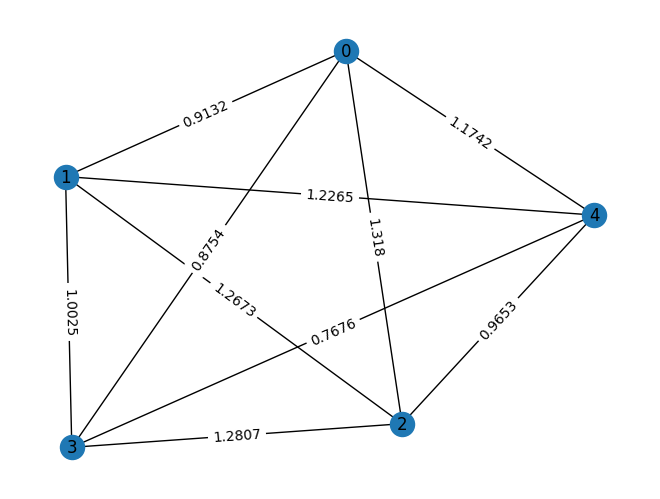

In [13]:
G = nx.fast_gnp_random_graph(5, 1, seed=1)
for _, _, w in G.edges(data=True):
    w['weight'] = round(np.random.uniform(0.7, 1.4), 4)
pos = nx.spring_layout(G, seed=1)
labels = nx.get_edge_attributes(G, 'weight')
nx.draw(G, pos, with_labels=True)
nx.draw_networkx_edge_labels(G, pos, edge_labels=labels)
print()

In [14]:
class NetGame:
    def __init__(self, G: nx.Graph):
        self.G = G
        self.edges = {(i, j): w['weight'] for i, j, w in G.edges(data=True)}
        self.nodes = G.nodes()
        self.adj_matrix = nx.adjacency_matrix(G).toarray()

    def get_next_state(self, state, action):
        # state is a set of nodes, last one where we are
        # action is the edge
        # next state is the node on the other side of the edge
        state.append(action[1])
        return state

    def get_valid_actions(self, state):
        # check all available edges from last node in the state
        last_node = state[-1]
        state_path = [(state[i], state[i+1]) for i in range(len(state)-1)] \
                + [(state[i+1], state[i]) for i in range(len(state)-1)]
        
        valid_actions = [e for e in G.edges(last_node) if e not in state_path]
        return valid_actions

    def check_win(self, state):
        return state[0] == state[-1] and len(state) > 1

    def get_value_and_terminated(self, state):
        valid_actions = self.get_valid_actions(state)

        if len(state) <= 1 and len(valid_actions) == 0:
            return -1, True
        if len(state) <= 1 and len(valid_actions) > 0:
            return 0, False
            
        edge_list = [(state[i], state[i+1]) for i in range(len(state)-1)]
        value =  1 / sum(self.G[edge[0]][edge[1]]['weight'] for edge in edge_list)
        
        if self.check_win(state):
            return value + 1, True
        if len(valid_actions) == 0:
            return value - 1, True
        return value, False

In [8]:
class Node:
    def __init__(self, game, args, state, parent=None, action_taken=None):
        self.game = game
        self.args = args
        self.state = state
        self.parent = parent
        self.action_taken = action_taken

        self.children = []
        self.expandable_actions = game.get_valid_actions(state)

        self.visit_count = 0
        self.value_sum = 0

    def is_fully_expanded(self):
        # node is fully expanded if there are no valid moves
        # node is fully expanded if there are children
        return len(self.expandable_actions) == 0 and len(self.children) > 0

    def select(self):
        # calculate ucb for all children
        # select child with best ucb
        best_child = None
        best_ucb = -np.inf

        for child in self.children:
            ucb = self.get_ucb(child)
            if ucb > best_ucb:
                best_child = child
                best_ucb = ucb
                
        return best_child

    def get_ucb(self, child):
        # exploration vs exploitation
        q_value = ((child.value_sum / child.visit_count) + 1) / 2
        return q_value + self.args['C'] * np.sqrt(np.log(self.visit_count)/child.visit_count)

    def expand(self):
        action_index = np.random.choice(range(len(self.expandable_actions)))
        action = self.expandable_actions[action_index]
        self.expandable_actions.pop(action_index)

        child_state = self.state.copy()
        child_state = self.game.get_next_state(child_state, action)

        child = Node(self.game, self.args, child_state, self, action)
        self.children.append(child)
        return child

    def simulate(self):
        value, is_terminal = self.game.get_value_and_terminated(self.state)
        if is_terminal:
            return value

        rollout_state = self.state.copy()
        while True:
            valid_actions = self.game.get_valid_actions(rollout_state)
            action_index = np.random.choice(range(len(valid_actions)))
            action = valid_actions[action_index]
            
            rollout_state = self.game.get_next_state(rollout_state, action)
            value, is_terminal = self.game.get_value_and_terminated(rollout_state)
            if is_terminal:
                return value

    def backpropagete(self, value):
        self.value_sum += value
        self.visit_count += 1
        if self.parent is not None:
            self.parent.backpropagete(value)
            

    
class MCTS:
    def __init__(self, game, args):
        self.game = game
        self.args = args

    def search(self, state):
        root = Node(self.game, self.args, state)
        
        for search in range(self.args['num_searches']):
            node = root
            # selection
            while node.is_fully_expanded():
                node = node.select()
                
            value, is_terminal = self.game.get_value_and_terminated(node.state)
            if not is_terminal:
                # expansion 
                node = node.expand()
                # simulation
                value = node.simulate()

            
            # backpropagation
            node.backpropagete(value)

        # return visit_count distribution
        valid_actions = self.game.get_valid_actions(state)
        action_probs = np.zeros(len(valid_actions))
        for child in root.children:
            action_probs[valid_actions.index(child.action_taken)] = child.visit_count

        action_probs /= np.sum(action_probs)
        return action_probs
        

In [9]:
args = {'C': 1.41, 'num_searches': 5000}
game = NetGame(G)
mcts = MCTS(game, args)

state = [0]
while True:
    valid_actions = game.get_valid_actions(state)
    if len(valid_actions) == 0:
        print("LOSS")
        break
        
    print("valid_actions", [(f"index {i}", j) for i, (_, j) in enumerate(valid_actions)])
    
    #action_index = int(input("choose action index"))
    #action = valid_actions[action_index]
    action_probs = mcts.search(state)
    action_index = np.argmax(action_probs)
    action = valid_actions[action_index]
    print(action_probs)

    state = game.get_next_state(state, action)
    
    value, terminated = game.get_value_and_terminated(state)

    print(value, state)
    
    if terminated == True:
        if state[0] == state[-1]:
            print("WON")
        else:
            print("LOSS")
        break
        
    print(state)

valid_actions [('index 0', 1), ('index 1', 2), ('index 2', 3), ('index 3', 4)]
[0.2536 0.2438 0.2498 0.2528]
0.18181818181818182 [0, 1]
[0, 1]
valid_actions [('index 0', 2), ('index 1', 3), ('index 2', 4)]
[0.3312 0.3262 0.3426]
0.10101010101010101 [0, 1, 4]
[0, 1, 4]
valid_actions [('index 0', 0), ('index 1', 2), ('index 2', 3)]
[0.4094 0.286  0.3046]
1.065359477124183 [0, 1, 4, 0]
WON
